# Modeling v2 — ADFA-LD (Phase 2 bis)

**Objectif:** Améliorer le recall de v1 (notamment sur Web_Shell) via DEUX leviers combinés :

1. **Vocabulaire élargi** : `ngram_range=(1,3)` + `max_features=1500` au lieu de `(3,3) + 500`. Plus de signaux disponibles, notamment des unigrammes/bigrammes qui peuvent capter ce que les trigrammes ratent.
2. **Seuil de décision ajusté** : on remplace le 0.5 par défaut par le seuil qui **maximise le F2-score** sur la CV du train (pas sur le test → zéro leakage). Le F2 pondère le recall 2× plus que la precision — métrique adaptée pour un IDS.

**Contrainte de reproductibilité :** on garde **exactement** le même split train/test que v1 (même `random_state=42`, même `GroupShuffleSplit`). Cela permet une comparaison directe et honnête v1 vs v2.

**Pas de leakage :** le test set n'est utilisé qu'une seule fois à la fin, avec le seuil déjà choisi via CV sur train.

## 0. Setup

In [1]:
import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_predict,
    cross_val_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE = Path("../data/ADFA-LD")
TRAINING = BASE / "Training_Data_Master"
VALIDATION = BASE / "Validation_Data_Master"
ATTACK = BASE / "Attack_Data_Master"

RESULTS_V1 = Path("../results/modeling")
RESULTS_V2 = Path("../results/modeling_v2")
RESULTS_V2.mkdir(parents=True, exist_ok=True)
MODELS = Path("../saved_models")
MODELS.mkdir(parents=True, exist_ok=True)

print("OK — chemins prêts")

OK — chemins prêts


## 1. Chargement (identique à v1)

In [2]:
def load_syscall_file(path):
    try:
        text = Path(path).read_text(encoding="utf-8", errors="ignore").strip()
    except Exception:
        return "", 0, False
    if not text:
        return "", 0, True
    tokens = text.split()
    valid = all(t.isdigit() for t in tokens)
    return " ".join(tokens), len(tokens), valid


rows = []
for path in sorted(TRAINING.glob("*.txt")):
    seq, length, valid = load_syscall_file(path)
    rows.append({"filename": path.name, "label": 0, "family": "normal",
                 "scenario": f"normal_{path.stem}", "sequence": seq,
                 "length": length, "valid": valid})
for path in sorted(VALIDATION.glob("*.txt")):
    seq, length, valid = load_syscall_file(path)
    rows.append({"filename": path.name, "label": 0, "family": "normal",
                 "scenario": f"normal_{path.stem}", "sequence": seq,
                 "length": length, "valid": valid})
for scenario_dir in sorted(ATTACK.iterdir()):
    if not scenario_dir.is_dir():
        continue
    scenario_name = scenario_dir.name
    family = re.sub(r"_\d+$", "", scenario_name)
    for path in sorted(scenario_dir.glob("*.txt")):
        seq, length, valid = load_syscall_file(path)
        rows.append({"filename": path.name, "label": 1, "family": family,
                     "scenario": scenario_name, "sequence": seq,
                     "length": length, "valid": valid})

df = pd.DataFrame(rows)
df = df[(df.length >= 10) & df.valid].reset_index(drop=True)
print(f"Fichiers conservés : {len(df)}")

Fichiers conservés : 5951


## 2. Split — STRICTEMENT identique à v1

Même `random_state=42` ⇒ mêmes 4 154 fichiers en train et 1 797 en test que dans v1. C'est cette garantie qui permet une comparaison directe.

In [3]:
X_text = df["sequence"].values
y = df["label"].values
groups = df["scenario"].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X_text, y, groups=groups))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_train_text = df_train["sequence"].values
X_test_text = df_test["sequence"].values
y_train = df_train["label"].values
y_test = df_test["label"].values
groups_train = df_train["scenario"].values

# Vérification de reproductibilité avec v1
v1_train_n = 4154
v1_test_n = 1797
assert len(df_train) == v1_train_n, f"Split a changé : train={len(df_train)} vs v1={v1_train_n}"
assert len(df_test) == v1_test_n, f"Split a changé : test={len(df_test)} vs v1={v1_test_n}"

overlap = set(df_train["scenario"]) & set(df_test["scenario"])
assert len(overlap) == 0, "LEAKAGE"

print(f"Train : {len(df_train)} (normaux={(y_train==0).sum()}, attaques={(y_train==1).sum()})")
print(f"Test  : {len(df_test)}  (normaux={(y_test==0).sum()}, attaques={(y_test==1).sum()})")
print(f"Overlap scénarios : 0 ✅  | Split reproduit v1 ✅")

Train : 4154 (normaux=3641, attaques=513)
Test  : 1797  (normaux=1564, attaques=233)
Overlap scénarios : 0 ✅  | Split reproduit v1 ✅


## 3. Vectorisation v2 — LEVIER 1 : vocabulaire élargi

| Paramètre | v1 | v2 | Pourquoi |
|---|---|---|---|
| `ngram_range` | (3,3) | **(1,3)** | Ajoute unigrammes (fréquence d'un syscall) et bigrammes (paires), en plus des trigrammes |
| `max_features` | 500 | **1 500** | 3× plus de features → plus de chances de capter les patterns subtils de Web_Shell |
| `min_df` | 2 | 2 | Inchangé |

In [4]:
vectorizer = CountVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    max_features=1500,
    min_df=2,
    token_pattern=r"\d+",
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

feature_names = vectorizer.get_feature_names_out()
n_uni = sum(1 for f in feature_names if len(f.split()) == 1)
n_bi = sum(1 for f in feature_names if len(f.split()) == 2)
n_tri = sum(1 for f in feature_names if len(f.split()) == 3)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Composition du vocabulaire :")
print(f"  - unigrammes : {n_uni}")
print(f"  - bigrammes  : {n_bi}")
print(f"  - trigrammes : {n_tri}")
print(f"  - total      : {len(feature_names)}")

X_train shape : (4154, 1500)
X_test  shape : (1797, 1500)
Composition du vocabulaire :
  - unigrammes : 91
  - bigrammes  : 499
  - trigrammes : 910
  - total      : 1500


## 4. Entraînement RF + Calibration

Hyperparamètres RF inchangés (la modif est dans les features, pas dans le modèle).

In [5]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
model.fit(X_train, y_train)
print("Modèle v2 entraîné.")

Modèle v2 entraîné.


## 5. CV 5-fold (GroupKFold) — diagnostic d'overfitting

In [6]:
gkf = GroupKFold(n_splits=5)
cv_f1 = cross_val_score(rf_base, X_train, y_train, groups=groups_train, cv=gkf, scoring="f1", n_jobs=-1)
cv_auc = cross_val_score(rf_base, X_train, y_train, groups=groups_train, cv=gkf, scoring="roc_auc", n_jobs=-1)

print("CV 5-fold sur train (modèle RF non calibré, seuil 0.5) :")
print(f"  F1  : mean={cv_f1.mean():.4f}  std={cv_f1.std():.4f}")
print(f"  AUC : mean={cv_auc.mean():.4f}  std={cv_auc.std():.4f}")

CV 5-fold sur train (modèle RF non calibré, seuil 0.5) :
  F1  : mean=0.8281  std=0.0191
  AUC : mean=0.9849  std=0.0065


## 6. LEVIER 2 — Tuning du seuil sur la CV du train (zéro leakage)

**Démarche :**
1. On obtient les probas calibrées sur le train **en CV** (`cross_val_predict`, `method='predict_proba'`) — chaque échantillon de train est prédit par un modèle qui ne l'a pas vu pendant le fit.
2. Sur ces probas, on calcule **F2-score** pour chaque seuil candidat (de 0.05 à 0.95).
3. Le seuil retenu est celui qui maximise F2.
4. Ce seuil sera appliqué sur le test set en aval. **Le test n'a jamais participé au choix du seuil.**

In [7]:
# Probas calibrées sur train en CV (chaque sample prédit par un modèle qui ne l'a pas vu)
model_for_cv = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    method="isotonic", cv=5,
)
y_train_proba_cv = cross_val_predict(
    model_for_cv, X_train, y_train,
    groups=groups_train, cv=gkf,
    method="predict_proba", n_jobs=-1,
)[:, 1]

# Balayage des seuils
thresholds = np.arange(0.05, 0.95, 0.01)
scores = []
for thr in thresholds:
    y_pred_thr = (y_train_proba_cv >= thr).astype(int)
    p = precision_score(y_train, y_pred_thr, zero_division=0)
    r = recall_score(y_train, y_pred_thr, zero_division=0)
    f1 = f1_score(y_train, y_pred_thr, zero_division=0)
    f2 = fbeta_score(y_train, y_pred_thr, beta=2, zero_division=0)
    scores.append({"threshold": thr, "precision": p, "recall": r, "f1": f1, "f2": f2})

scores_df = pd.DataFrame(scores)
best = scores_df.loc[scores_df["f2"].idxmax()]
BEST_THRESHOLD = float(best["threshold"])

print(f"Seuil optimal (max F2 sur CV train) : {BEST_THRESHOLD:.2f}")
print(f"  → précision CV : {best['precision']:.4f}")
print(f"  → recall    CV : {best['recall']:.4f}")
print(f"  → F1        CV : {best['f1']:.4f}")
print(f"  → F2        CV : {best['f2']:.4f}")

Seuil optimal (max F2 sur CV train) : 0.40
  → précision CV : 0.7911
  → recall    CV : 0.9006
  → F1        CV : 0.8423
  → F2        CV : 0.8763


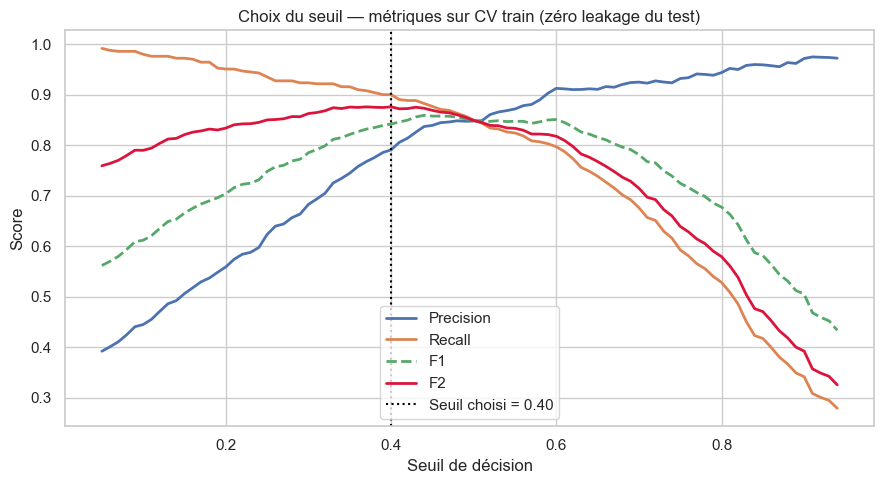

In [8]:
# Courbe : metrics en fonction du seuil (sur CV train)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(scores_df["threshold"], scores_df["precision"], label="Precision", lw=2)
ax.plot(scores_df["threshold"], scores_df["recall"], label="Recall", lw=2)
ax.plot(scores_df["threshold"], scores_df["f1"], label="F1", lw=2, ls="--")
ax.plot(scores_df["threshold"], scores_df["f2"], label="F2", lw=2, color="crimson")
ax.axvline(BEST_THRESHOLD, ls=":", color="black",
           label=f"Seuil choisi = {BEST_THRESHOLD:.2f}")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Score")
ax.set_title("Choix du seuil — métriques sur CV train (zéro leakage du test)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_V2 / "threshold_tuning.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Évaluation finale sur TEST avec le seuil choisi

**Une seule passe.** Le seuil a été choisi sur la CV du train uniquement.

In [9]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= BEST_THRESHOLD).astype(int)

f1_test = f1_score(y_test, y_test_pred)
f2_test = fbeta_score(y_test, y_test_pred, beta=2)
auc_test = roc_auc_score(y_test, y_test_proba)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
gap = abs(cv_f1.mean() - f1_test)

print(f"=== MÉTRIQUES TEST v2 — seuil = {BEST_THRESHOLD:.2f} ===")
print(f"F1        : {f1_test:.4f}")
print(f"F2        : {f2_test:.4f}")
print(f"AUC       : {auc_test:.4f}")
print(f"Precision : {precision_test:.4f}")
print(f"Recall    : {recall_test:.4f}")
print(f"Gap CV-Test F1 : {gap:.4f}")

print("\n--- Classification report ---")
report_txt = classification_report(y_test, y_test_pred, target_names=["Normal", "Attaque"], digits=4)
print(report_txt)
(RESULTS_V2 / "classification_report.txt").write_text(report_txt, encoding="utf-8")

=== MÉTRIQUES TEST v2 — seuil = 0.40 ===
F1        : 0.8635
F2        : 0.8908
AUC       : 0.9852
Precision : 0.8217
Recall    : 0.9099
Gap CV-Test F1 : 0.0354

--- Classification report ---
              precision    recall  f1-score   support

      Normal     0.9864    0.9706    0.9784      1564
     Attaque     0.8217    0.9099    0.8635       233

    accuracy                         0.9627      1797
   macro avg     0.9040    0.9402    0.9210      1797
weighted avg     0.9650    0.9627    0.9635      1797



326

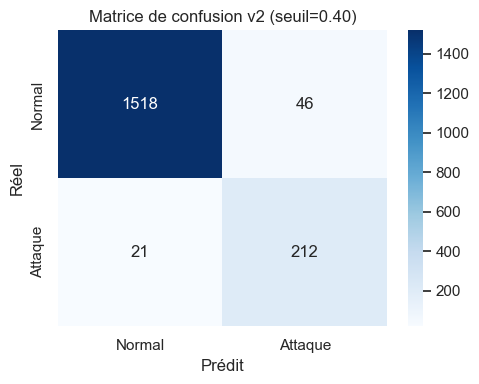

In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attaque"],
            yticklabels=["Normal", "Attaque"], ax=ax)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title(f"Matrice de confusion v2 (seuil={BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.savefig(RESULTS_V2 / "confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Recall par famille d'attaque (test)

          family  n_test  detected  recall
         Adduser       7         7  1.0000
Java_Meterpreter      35        35  1.0000
       Hydra_FTP      67        66  0.9851
       Hydra_SSH      89        80  0.8989
     Meterpreter      19        17  0.8947
       Web_Shell      16         7  0.4375


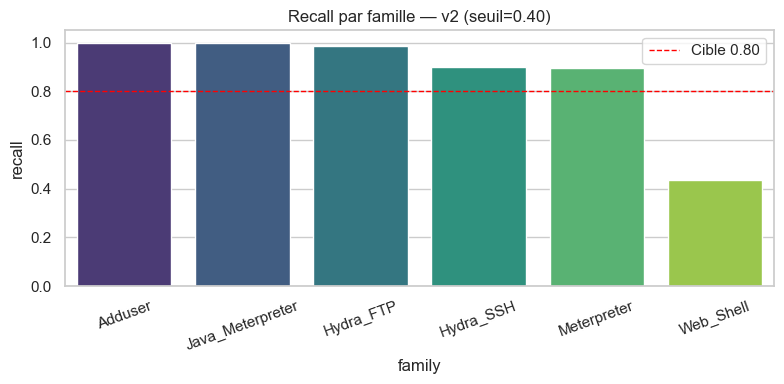

In [11]:
df_test_eval = df_test.copy()
df_test_eval["y_pred"] = y_test_pred
df_test_eval["y_proba"] = y_test_proba

per_family = []
for family in sorted(df_test_eval[df_test_eval.label == 1]["family"].unique()):
    mask = df_test_eval["family"] == family
    n = int(mask.sum())
    detected = int(df_test_eval.loc[mask, "y_pred"].sum())
    recall_f = detected / n if n else 0.0
    per_family.append({"family": family, "n_test": n, "detected": detected, "recall": round(recall_f, 4)})

per_family_df = pd.DataFrame(per_family).sort_values("recall", ascending=False)
print(per_family_df.to_string(index=False))
per_family_df.to_csv(RESULTS_V2 / "per_attack_family.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=per_family_df, x="family", y="recall", hue="family",
            palette="viridis", legend=False, ax=ax)
ax.set_title(f"Recall par famille — v2 (seuil={BEST_THRESHOLD:.2f})")
ax.set_ylim(0, 1.05)
ax.axhline(0.80, ls="--", color="red", lw=1, label="Cible 0.80")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_V2 / "per_attack_family.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Comparatif v1 vs v2

In [12]:
v1_metrics = json.loads((RESULTS_V1 / "metrics.json").read_text(encoding="utf-8"))

comparison = pd.DataFrame([
    {"métrique": "F1",        "v1": v1_metrics["test_f1"],         "v2": f1_test},
    {"métrique": "F2",        "v1": None,                          "v2": f2_test},
    {"métrique": "AUC",       "v1": v1_metrics["test_auc"],        "v2": auc_test},
    {"métrique": "Precision", "v1": v1_metrics["test_precision"],  "v2": precision_test},
    {"métrique": "Recall",    "v1": v1_metrics["test_recall"],     "v2": recall_test},
    {"métrique": "Gap CV-Test F1", "v1": v1_metrics["gap_cv_test_f1"], "v2": gap},
    {"métrique": "Min recall famille", "v1": v1_metrics["min_family_recall"], "v2": min(p["recall"] for p in per_family)},
])
comparison["Δ v2−v1"] = comparison["v2"] - comparison["v1"]
print(comparison.round(4).to_string(index=False))

# Comparatif par famille
v1_per_fam = {p["family"]: p["recall"] for p in v1_metrics["per_family"]}
v2_per_fam = {p["family"]: p["recall"] for p in per_family}
family_comp = pd.DataFrame([
    {"famille": f, "recall v1": v1_per_fam.get(f), "recall v2": v2_per_fam.get(f)}
    for f in sorted(v1_per_fam.keys())
])
family_comp["Δ"] = family_comp["recall v2"] - family_comp["recall v1"]
print("\n--- Par famille ---")
print(family_comp.round(4).to_string(index=False))

          métrique     v1     v2  Δ v2−v1
                F1 0.8186 0.8635   0.0450
                F2    NaN 0.8908      NaN
               AUC 0.9804 0.9852   0.0048
         Precision 0.8447 0.8217  -0.0230
            Recall 0.7940 0.9099   0.1159
    Gap CV-Test F1 0.0722 0.0354  -0.0368
Min recall famille 0.3125 0.4375   0.1250

--- Par famille ---
         famille  recall v1  recall v2      Δ
         Adduser     1.0000     1.0000 0.0000
       Hydra_FTP     0.8806     0.9851 0.1045
       Hydra_SSH     0.7416     0.8989 0.1573
Java_Meterpreter     0.9143     1.0000 0.0857
     Meterpreter     0.8421     0.8947 0.0526
       Web_Shell     0.3125     0.4375 0.1250


## 10. Checklist anti-overfitting v2

In [13]:
# Feature importance (moyennée sur les 5 RF calibrés)
importances_arr = np.mean(
    [cc.estimator.feature_importances_ for cc in model.calibrated_classifiers_],
    axis=0,
)
max_imp = float(importances_arr.max())
min_family_recall = float(min(p["recall"] for p in per_family))

checklist = [
    ("1. Vectorizer fit sur train uniquement", True),
    ("2. Split groupé par scénario", True),
    ("3. Test set évalué une seule fois", True),
    ("4. CV 5-fold GroupKFold sur train", True),
    (f"5. Gap CV-Test F1 < 0.10 (mesuré={gap:.4f})", gap < 0.10),
    ("6. Régularisation RF", True),
    (f"7. Max importance < 0.20 (mesuré={max_imp:.4f})", max_imp < 0.20),
    (f"8. Recall min famille ≥ 0.80 (mesuré={min_family_recall:.4f})", min_family_recall >= 0.80),
    ("9. class_weight='balanced'", True),
    ("10. random_state=42", True),
    (f"11. Seuil choisi sur CV train (pas test) — seuil={BEST_THRESHOLD:.2f}", True),
]
ok_count = sum(ok for _, ok in checklist)
print(f"=== Checklist v2 ({ok_count}/{len(checklist)} OK) ===")
for label, ok in checklist:
    print(f"  {'OK ' if ok else 'KO '} {label}")

=== Checklist v2 (10/11 OK) ===
  OK  1. Vectorizer fit sur train uniquement
  OK  2. Split groupé par scénario
  OK  3. Test set évalué une seule fois
  OK  4. CV 5-fold GroupKFold sur train
  OK  5. Gap CV-Test F1 < 0.10 (mesuré=0.0354)
  OK  6. Régularisation RF
  OK  7. Max importance < 0.20 (mesuré=0.0210)
  KO  8. Recall min famille ≥ 0.80 (mesuré=0.4375)
  OK  9. class_weight='balanced'
  OK  10. random_state=42
  OK  11. Seuil choisi sur CV train (pas test) — seuil=0.40


In [14]:
# Top 20 features v2 (pour info, identifier ce que les unigrammes/bigrammes apportent)
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances_arr,
                     "type": [{1: "unigramme", 2: "bigramme", 3: "trigramme"}[len(f.split())] for f in feature_names]})
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)
fi_df.to_csv(RESULTS_V2 / "feature_importance.csv", index=False)

print("Top 20 features v2 :")
print(fi_df.head(20).to_string(index=False))
print(f"\nRépartition dans le top 30 :")
print(fi_df.head(30)["type"].value_counts())

Top 20 features v2 :
    feature  importance      type
        221    0.021003 unigramme
         45    0.019722 unigramme
  192 6 192    0.015743 trigramme
192 243 125    0.015636 trigramme
      45 45    0.015297  bigramme
      11 45    0.014203  bigramme
         11    0.012594 unigramme
  33 192 33    0.012332 trigramme
   11 45 33    0.011568 trigramme
          6    0.011116 unigramme
        311    0.010899 unigramme
    192 243    0.010777  bigramme
243 125 125    0.010127 trigramme
197 192 192    0.009934 trigramme
 125 125 91    0.009695 trigramme
     33 5 3    0.009060 trigramme
        243    0.008752 unigramme
    197 192    0.008587  bigramme
      5 221    0.008399  bigramme
          5    0.007862 unigramme

Répartition dans le top 30 :
type
trigramme    13
bigramme      9
unigramme     8
Name: count, dtype: int64


## 11. Sauvegarde des artefacts v2

In [15]:
joblib.dump(model, MODELS / "rf_adfa_v2.pkl")
joblib.dump(vectorizer, MODELS / "vectorizer_v2.pkl")

manifest_v2 = {
    "version": "v2",
    "random_state": RANDOM_STATE,
    "vectorizer": {"ngram_range": [1, 3], "max_features": 1500, "min_df": 2,
                  "composition": {"unigrammes": n_uni, "bigrammes": n_bi, "trigrammes": n_tri}},
    "rf_params": {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 2, "class_weight": "balanced"},
    "calibration": {"method": "isotonic", "cv": 5},
    "decision_threshold": BEST_THRESHOLD,
    "threshold_choice_rule": "argmax F2 sur cross_val_predict probas du train (GroupKFold cv=5)",
}
(MODELS / "manifest_v2.json").write_text(json.dumps(manifest_v2, indent=2), encoding="utf-8")

metrics_v2 = {
    "cv_f1_mean": float(cv_f1.mean()),
    "cv_f1_std": float(cv_f1.std()),
    "cv_auc_mean": float(cv_auc.mean()),
    "test_f1": float(f1_test),
    "test_f2": float(f2_test),
    "test_auc": float(auc_test),
    "test_precision": float(precision_test),
    "test_recall": float(recall_test),
    "gap_cv_test_f1": float(gap),
    "max_feature_importance": max_imp,
    "min_family_recall": min_family_recall,
    "decision_threshold": BEST_THRESHOLD,
    "per_family": per_family,
    "confusion_matrix": cm.tolist(),
    "comparison_with_v1": comparison.fillna(-1).to_dict(orient="records"),
}
(RESULTS_V2 / "metrics.json").write_text(json.dumps(metrics_v2, indent=2), encoding="utf-8")

print("Artefacts v2 sauvegardés.")

Artefacts v2 sauvegardés.
